# Auto-encoders for image compression, generation and denoising



### Imports python

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

#Import pytorch:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision
from torch.utils.tensorboard import SummaryWriter

# 1. Implementing an auto-encoder on MNIST image dataset

## 1.1 Data loading and visualization

shape X train :  torch.Size([60000, 28, 28])
shape X test :  torch.Size([10000, 28, 28])


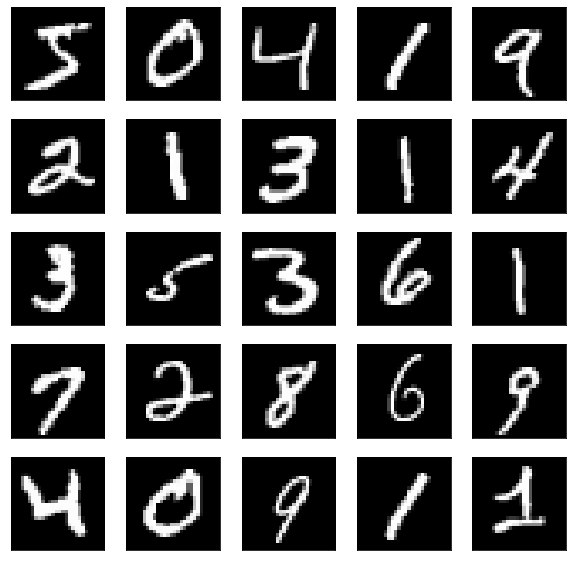

In [2]:
# Get MNIST data
X_train = torchvision.datasets.MNIST(root='./data', train=True, download=True).data
X_test = torchvision.datasets.MNIST(root='./data', train=False, download=True).data

# Normalise between 0 and 1
X_train = (X_train/255.).type(torch.FloatTensor)
X_test = (X_test/255.).type(torch.FloatTensor)

print('shape X train : ', X_train.shape)
print('shape X test : ', X_test.shape)

# Create datasets
mnistTrainSet_clean = TensorDataset(X_train, X_train)
mnistTestSet_clean = TensorDataset(X_test, X_test)

# Display a few images
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.gray()
    plt.imshow(X_train[i],vmin=0,vmax=1)
    

## 1.2 Auto-encoder with 1 dense hidden layer

In [3]:
input_dim = 28*28

class AutoEncoderMLP(nn.Module):
    def __init__(self,embedding_dim):
        super(AutoEncoderMLP, self).__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(start_dim = 1),
            nn.Linear(input_dim, embedding_dim),
            nn.ReLU()
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(embedding_dim, input_dim),
            nn.Sigmoid()
        )
        
            
    def encode(self, x):
        x = self.encoder(x)
        
        return x
            
    def decode(self, x):
        x = self.decoder(x)
        
        return x
            
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        x = x.reshape((x.shape[0],28,28))
        
        return x

torch.manual_seed(0);

In [4]:
# Latent space dimension (embedding)
embedding_dim = 32

# Model creation
modelMLP = AutoEncoderMLP(embedding_dim=embedding_dim)

# Print architecture:
print(modelMLP)

AutoEncoderMLP(
  (encoder): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=32, bias=True)
    (2): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=784, bias=True)
    (1): Sigmoid()
  )
)


In [5]:
# Hyperparameters
N_epochs = 10
batch_size = 256
learning_rate = 0.001

# dataloaders
mnistTrainLoader = DataLoader(mnistTrainSet_clean, batch_size=batch_size,shuffle=True, num_workers=0)

# FLoss function
loss_function = nn.MSELoss()

# Optimizer
optimizer = torch.optim.Adam(modelMLP.parameters(),lr=learning_rate)

In [6]:
# Training procedure for a model, using a dataloader, optimiser and number of epochs
def train(model, data_loader, opt, n_epochs):
    losses = []  
    i=0
    for epoch in range(n_epochs):  # Loop over epochs
        running_loss = 0.0

        for features, labels in data_loader:      

            output = model(features)
            loss = loss_function(output,labels)
            losses.append(loss.item())
            opt.zero_grad()
            loss.backward()
            opt.step()
            
            # print statistics
            running_loss += loss.item()
            if i % 10 == 9:    
                print('[Epoch : %d, iteration: %5d] loss: %.3f'%
                      (epoch + 1, i + 1, running_loss / 10))
                running_loss = 0.0
            i+=1   

    print('Training done')
    return losses

### Training

In [7]:
losses = train(modelMLP, mnistTrainLoader, optimizer, N_epochs)

[Epoch : 1, iteration:    10] loss: 0.224
[Epoch : 1, iteration:    20] loss: 0.185
[Epoch : 1, iteration:    30] loss: 0.132
[Epoch : 1, iteration:    40] loss: 0.094
[Epoch : 1, iteration:    50] loss: 0.079
[Epoch : 1, iteration:    60] loss: 0.072
[Epoch : 1, iteration:    70] loss: 0.069
[Epoch : 1, iteration:    80] loss: 0.068
[Epoch : 1, iteration:    90] loss: 0.066
[Epoch : 1, iteration:   100] loss: 0.064
[Epoch : 1, iteration:   110] loss: 0.063
[Epoch : 1, iteration:   120] loss: 0.061
[Epoch : 1, iteration:   130] loss: 0.060
[Epoch : 1, iteration:   140] loss: 0.058
[Epoch : 1, iteration:   150] loss: 0.057
[Epoch : 1, iteration:   160] loss: 0.056
[Epoch : 1, iteration:   170] loss: 0.054
[Epoch : 1, iteration:   180] loss: 0.053
[Epoch : 1, iteration:   190] loss: 0.051
[Epoch : 1, iteration:   200] loss: 0.050
[Epoch : 1, iteration:   210] loss: 0.049
[Epoch : 1, iteration:   220] loss: 0.048
[Epoch : 1, iteration:   230] loss: 0.047
[Epoch : 2, iteration:   240] loss

### Visualisation

#### Display the evolution of the loss during training

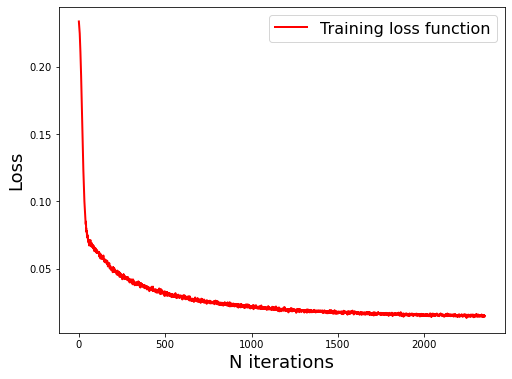

In [8]:
def display(losses,label='Training loss function'):
    # Display loss evolution
    fig, axes = plt.subplots(figsize=(8,6))
    axes.plot(losses,'r-',lw=2,label=label)
    axes.set_xlabel('N iterations',fontsize=18)
    axes.set_ylabel('Loss',fontsize=18)
    plt.legend(loc='upper right',fontsize=16)

# # Display loss evolution
display(losses)

### Display image reconstructions

In [9]:
def display_reconstructions(img_initial, img_reconstructed, n=8):
    plt.figure(figsize=(20, 4))
    for i in range(n):
        # image original
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(img_initial[i,:,:].reshape(28, 28),vmin=0,vmax=1)
        plt.gray()
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

        # image reconstructed
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(img_reconstructed[i,:,:],vmin=0,vmax=1)
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
    plt.show()

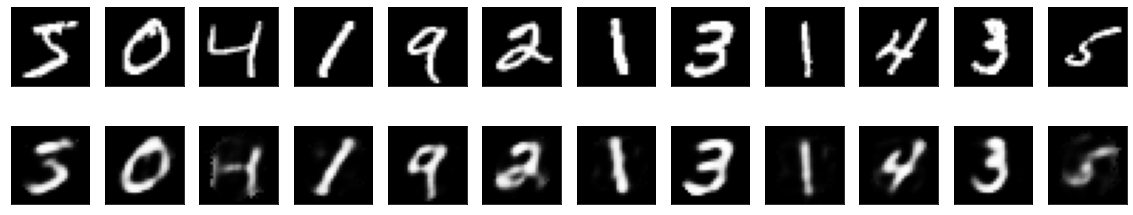

In [10]:
# Compute and display example reconstructed images on the training dataset
n=12
img = X_train[:n,:,:]
rec = modelMLP(img)

# Compute reconstructed images

# Display:
display_reconstructions(img, rec.detach().numpy(), n)

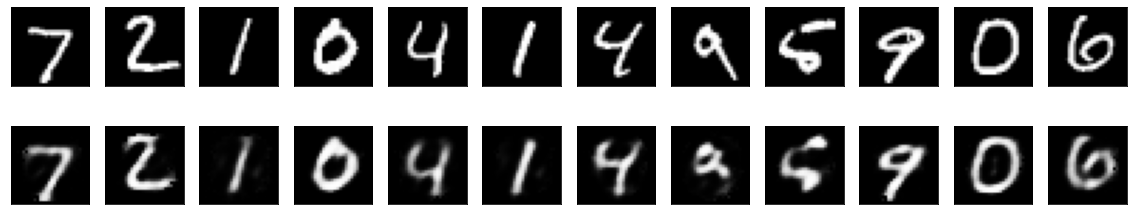

In [11]:
# Compute and display example reconstructed images on the test dataset
n=12
img = X_test[:n,:,:]
rec = modelMLP(img)

# Compute reconstructed images

# Display:
display_reconstructions(img, rec.detach().numpy(), n)

## 1.4 Image generation through interpolation on the latent space

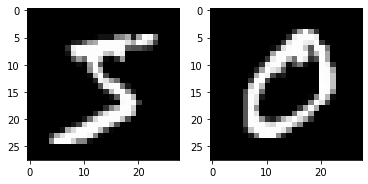

In [12]:
# Choice of images to interpolate
img1 = X_train[0,:,:]
img2 = X_train[1,:,:]

# Display the 2 images
plt.subplot(1,2,1)
plt.gray()
plt.imshow(img1,vmin=0,vmax=1)
plt.subplot(1,2,2)
plt.imshow(img2,vmin=0,vmax=1);

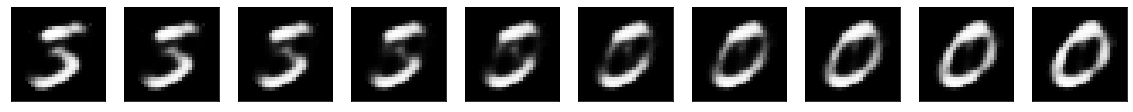

In [13]:
# Compute codes z1 and z2
z1 = modelMLP.encode(img1[None,None,:,:])
z2 = modelMLP.encode(img2[None,None,:,:])

# Computed interpolated images and display
plt.figure(figsize=(20,4))
num = 10
i=0
for k in np.linspace(0,1,num):
    i+=1
    z = torch.lerp(z1,z2,k)
    img = modelMLP.decode(z)
    img = img.reshape((28,28))
    plt.subplot(1,num,i)
    plt.gray()
    plt.imshow(img.detach().numpy(),vmin=0,vmax=1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

In [14]:
class AutoEncoderCNN(nn.Module):
    def __init__(self,nb_channels, embedding_dim):
        super(AutoEncoderCNN, self).__init__()
        # input shape: [batch, 1, 28, 28]
        self.encoder = nn.Sequential(
            nn.Conv2d(1,nb_channels, kernel_size=(5,5)),   #shape: [batch, nb_channels, 24,24]
            nn.ReLU(),
            nn.Conv2d(nb_channels,nb_channels, kernel_size=(5,5), stride=2), #shape: [batch, nb_channels, 10,10]
            nn.ReLU(),
            nn.Conv2d(nb_channels,nb_channels, kernel_size=(3,3), stride=2), #shape: [batch, nb_channels, 4,4]
            nn.ReLU(),
            nn.Conv2d(nb_channels,embedding_dim, kernel_size=(4,4)) #shape: [batch, embedding_dim, 1,1]
        )
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(embedding_dim, nb_channels, kernel_size=(4,4), stride = 1), #shape: [batch, nb_channels, 4,4]
            nn.ReLU(),
            nn.ConvTranspose2d(nb_channels, nb_channels, kernel_size=(3,3), stride = 2, output_padding=1), #shape: [batch, nb_channels, 10,10]
            nn.ReLU(),
            nn.ConvTranspose2d(nb_channels, nb_channels, kernel_size=(5,5), stride = 2, output_padding=1), #shape: [batch, nb_channels, 24,24]
            nn.ReLU(),
            nn.ConvTranspose2d(nb_channels, 1, kernel_size=(5,5), stride = 1)
            #shape: [batch, 1, 28,28]
        )  
    def encode(self, x):
        x = self.encoder(x)
        return x
            
    def decode(self, x):
        x = self.decoder(x)
        return x
            
    def forward(self, x):
        #shape: [batch, 28,28] -> #shape: [batch, 1, 28,28]
        x = self.encoder(x[:,None,:,:])
        x = self.decoder(x)
        #shape: [batch, 1, 28,28] -> #shape: [batch, 28,28]
        x = x.reshape((x.shape[0],28,28))
        return x   


In [15]:
# Network creation
modelcnn = AutoEncoderCNN(nb_channels=16,embedding_dim=16)

# Print the architecture
print(modelcnn)

AutoEncoderCNN(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 16, kernel_size=(5, 5), stride=(2, 2))
    (3): ReLU()
    (4): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2))
    (5): ReLU()
    (6): Conv2d(16, 16, kernel_size=(4, 4), stride=(1, 1))
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(16, 16, kernel_size=(4, 4), stride=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(16, 16, kernel_size=(3, 3), stride=(2, 2), output_padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(16, 16, kernel_size=(5, 5), stride=(2, 2), output_padding=(1, 1))
    (5): ReLU()
    (6): ConvTranspose2d(16, 1, kernel_size=(5, 5), stride=(1, 1))
  )
)


### Training

In [16]:
# Hyperparameters
N_epochs = 2
batch_size = 256
learning_rate = 0.001

In [17]:
loss_function = nn.MSELoss()

In [18]:
# Optimiser
optimizer = torch.optim.Adam(modelcnn.parameters(),lr=learning_rate)

In [19]:
# DataLoader
mnistTrainLoader = DataLoader(mnistTrainSet_clean, batch_size=batch_size,shuffle=True, num_workers=0)

In [20]:
losses = train(modelcnn, mnistTrainLoader, optimizer, N_epochs)

[Epoch : 1, iteration:    10] loss: 0.102
[Epoch : 1, iteration:    20] loss: 0.081
[Epoch : 1, iteration:    30] loss: 0.073
[Epoch : 1, iteration:    40] loss: 0.070
[Epoch : 1, iteration:    50] loss: 0.066
[Epoch : 1, iteration:    60] loss: 0.064
[Epoch : 1, iteration:    70] loss: 0.062
[Epoch : 1, iteration:    80] loss: 0.059
[Epoch : 1, iteration:    90] loss: 0.054
[Epoch : 1, iteration:   100] loss: 0.050
[Epoch : 1, iteration:   110] loss: 0.046
[Epoch : 1, iteration:   120] loss: 0.044
[Epoch : 1, iteration:   130] loss: 0.041
[Epoch : 1, iteration:   140] loss: 0.038
[Epoch : 1, iteration:   150] loss: 0.036
[Epoch : 1, iteration:   160] loss: 0.034
[Epoch : 1, iteration:   170] loss: 0.032
[Epoch : 1, iteration:   180] loss: 0.031
[Epoch : 1, iteration:   190] loss: 0.029
[Epoch : 1, iteration:   200] loss: 0.029
[Epoch : 1, iteration:   210] loss: 0.028
[Epoch : 1, iteration:   220] loss: 0.027
[Epoch : 1, iteration:   230] loss: 0.026
[Epoch : 2, iteration:   240] loss

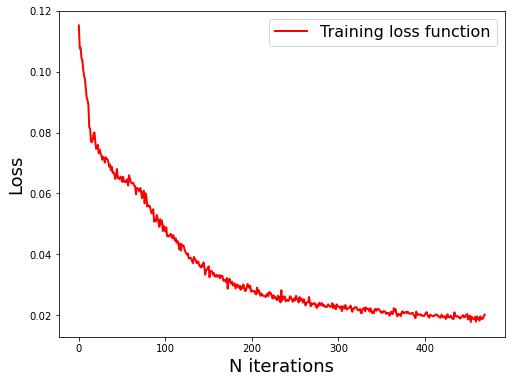

In [21]:
# Display loss
display(losses)

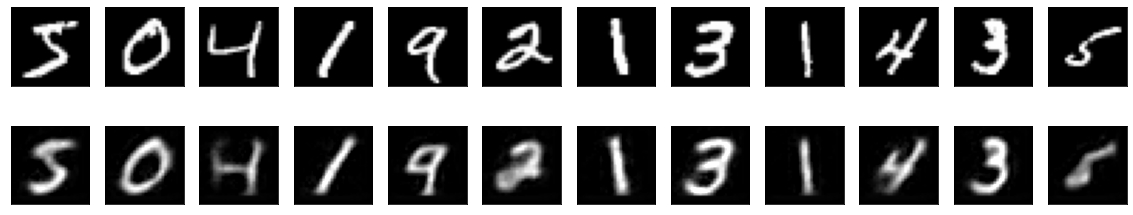

In [23]:
# Compute and display example reconstructed images on the training dataset
n=12
img = X_train[:n,:,:]
rec = modelcnn(img)

# Compute reconstructed images

# Display:
display_reconstructions(img, rec.detach().numpy(), n)

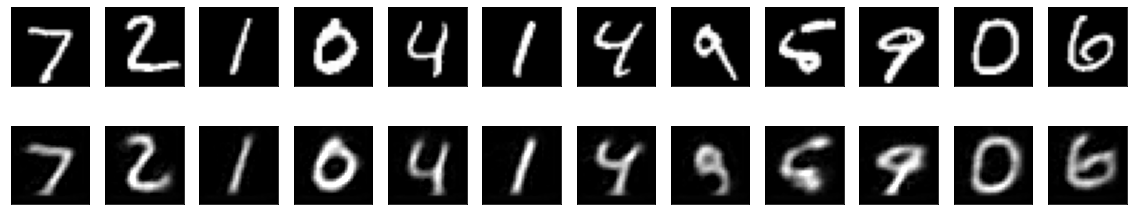

In [24]:
# Compute and display example reconstructed images on the test dataset
n=12
img = X_test[:n,:,:]
rec = modelcnn(img)

# Compute reconstructed images

# Display:
display_reconstructions(img, rec.detach().numpy(), n)

# 2. Image denoising

### Denoising dataset preparation

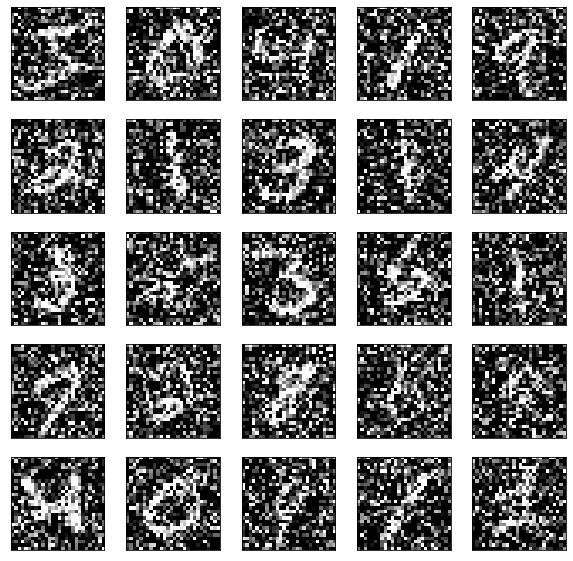

In [53]:
# Noise level (Modify here)
noise_scale = 0.6

# Add noise
noise = np.random.normal(loc=0, scale=noise_scale, size=X_train.shape)
X_train_noisy = X_train + noise
X_train_noisy = np.clip(X_train_noisy, 0., 1.).type(torch.FloatTensor)

noise = np.random.normal(loc=0, scale=noise_scale, size=X_test.shape)
X_test_noisy = X_test + noise
X_test_noisy = np.clip(X_test_noisy, 0., 1.).type(torch.FloatTensor)

# Datasets building

mnistTrainSet_denoise = TensorDataset(X_train_noisy, X_train)
mnistTestSet_denoise = TensorDataset(X_test_noisy, X_test)

# Display a few noisy images
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train_noisy[i])
    plt.gray()

### Building the model

In [54]:
# Build the model
denoiser = AutoEncoderMLP(embedding_dim=64)

### Train

In [55]:
# Hyperparameters
N_epochs = 10
batch_size = 256
learning_rate = 0.001

In [56]:
# Dataloader
mnistnoisyTrainLoader = DataLoader(mnistTrainSet_denoise, batch_size=batch_size,shuffle=True, num_workers=0)

In [57]:
# Optimizer
optimizer = torch.optim.Adam(denoiser.parameters(),lr=learning_rate)

In [58]:
losses = train(denoiser, mnistnoisyTrainLoader, optimizer, N_epochs)

[Epoch : 1, iteration:    10] loss: 0.202
[Epoch : 1, iteration:    20] loss: 0.119
[Epoch : 1, iteration:    30] loss: 0.078
[Epoch : 1, iteration:    40] loss: 0.071
[Epoch : 1, iteration:    50] loss: 0.070
[Epoch : 1, iteration:    60] loss: 0.068
[Epoch : 1, iteration:    70] loss: 0.067
[Epoch : 1, iteration:    80] loss: 0.067
[Epoch : 1, iteration:    90] loss: 0.066
[Epoch : 1, iteration:   100] loss: 0.066
[Epoch : 1, iteration:   110] loss: 0.065
[Epoch : 1, iteration:   120] loss: 0.064
[Epoch : 1, iteration:   130] loss: 0.063
[Epoch : 1, iteration:   140] loss: 0.062
[Epoch : 1, iteration:   150] loss: 0.061
[Epoch : 1, iteration:   160] loss: 0.059
[Epoch : 1, iteration:   170] loss: 0.057
[Epoch : 1, iteration:   180] loss: 0.056
[Epoch : 1, iteration:   190] loss: 0.055
[Epoch : 1, iteration:   200] loss: 0.054
[Epoch : 1, iteration:   210] loss: 0.052
[Epoch : 1, iteration:   220] loss: 0.051
[Epoch : 1, iteration:   230] loss: 0.050
[Epoch : 2, iteration:   240] loss

### Visualisation

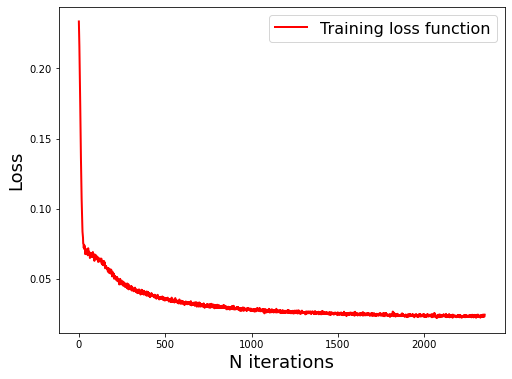

In [59]:
# Display loss:
display(losses)

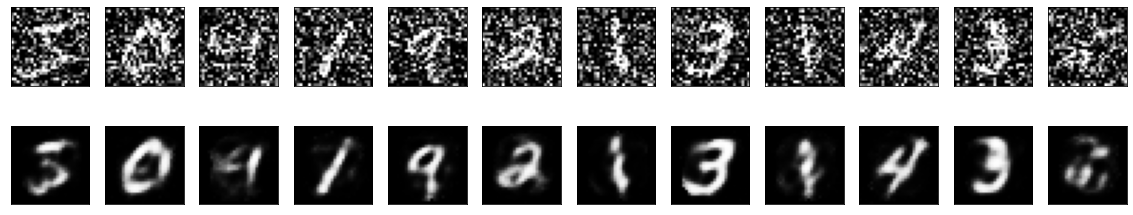

In [60]:
# Compute and display example reconstructed test on the training dataset
n=12
img = X_train_noisy[:n,:,:]
rec = denoiser(img)

# Compute reconstructed images

# Display:
display_reconstructions(img, rec.detach().numpy(), n)